In [370]:
import numpy as np
from pathlib import Path
from scipy.spatial import distance_matrix

from model_mlene import (
    process_geo,
    TB_Hamiltonian,
    initialise_moments_smart,
    find_moments,
    generate_allmaxcon_system_file,map_site_types
)
from func import blank_rect_lattice


In [466]:
xm1, ym1, subsm1, edgesm1, pred_moments1 = np.loadtxt('temp4.gz', unpack=True, delimiter=',')

print(len(xm1))          # number of atoms
print(np.unique(subsm1)) # should be 0/1 (A/B)
print(np.unique(edgesm1))# types of sites
print(len(pred_moments1))

5501
[-1.  1.]
[0. 1. 2. 3.]
5501


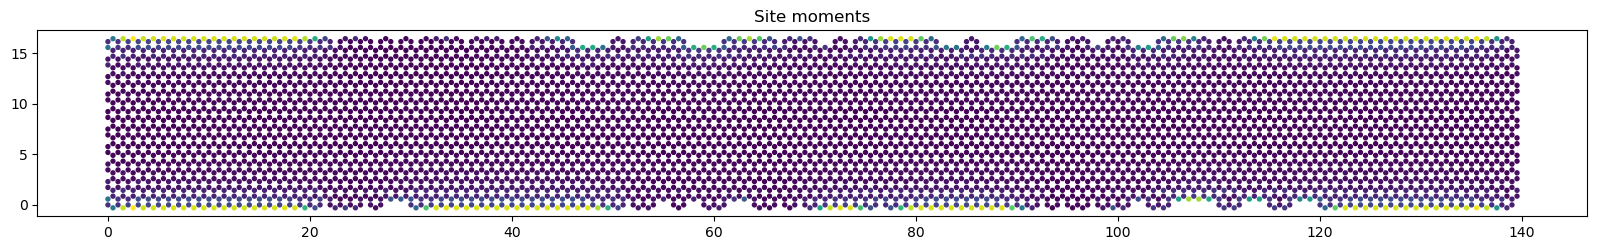

In [472]:
plt.figure(figsize=(20,30))
# plt.scatter(x,y, c=abs(moments), cmap='coolwarm',s=2)
plt.scatter(xm1,ym1, c=abs(pred_moments1), cmap='viridis',s=8)
plt.gca().set_aspect('equal')
# plt.colorbar(label='Magnetic moment')
plt.title('Site moments')
plt.show()

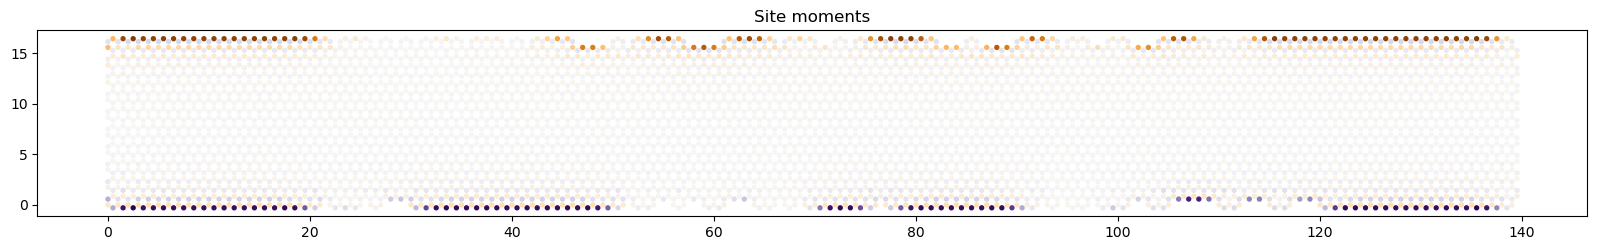

In [500]:
plt.figure(figsize=(20,30))
# plt.scatter(x,y, c=abs(moments), cmap='coolwarm',s=2)
plt.scatter(xm1,ym1, c=subsm1*pred_moments1, cmap='PuOr',s=8)
plt.gca().set_aspect('equal')
# plt.colorbar(label='Magnetic moment')
plt.title('Site moments')
plt.show()

In [476]:
data4 = np.load('temp4_run00_transport.npz')

es4 = data4['energies']
trans4 = data4['trans']
trans_up4 = data4['trans_up']
trans_down4 = data4['trans_down']

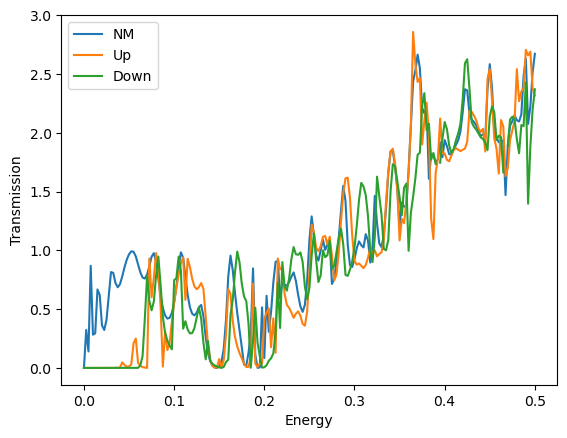

In [478]:
plt.plot(es4, trans4, label='NM')
plt.plot(es4, trans_up4, label='Up')
plt.plot(es4, trans_down4, label='Down')

plt.xlabel('Energy')
plt.ylabel('Transmission')
plt.legend()
plt.show()

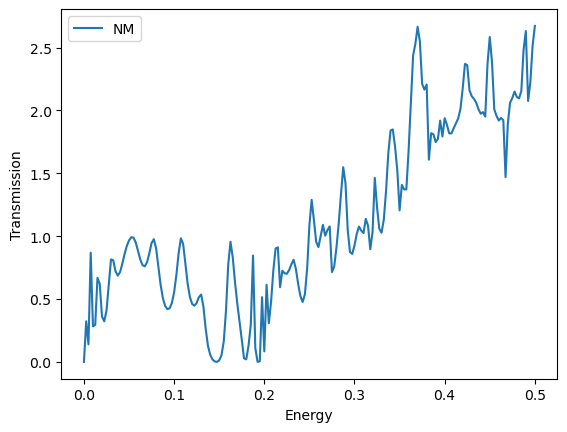

In [480]:
plt.plot(es4, trans4, label='NM')

plt.xlabel('Energy')
plt.ylabel('Transmission')
plt.legend()
plt.show()

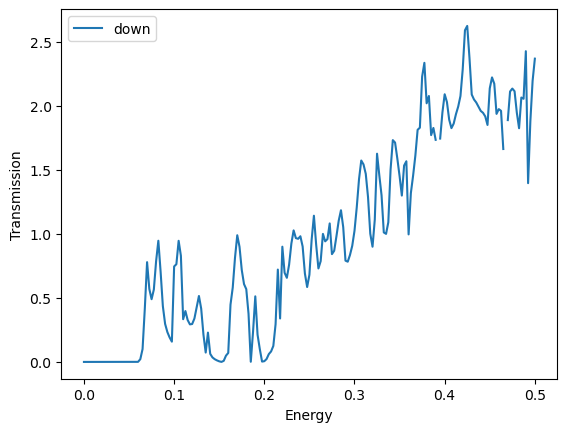

In [486]:
plt.plot(es4, trans_down4, label='down')

plt.xlabel('Energy')
plt.ylabel('Transmission')
plt.legend()
plt.show()

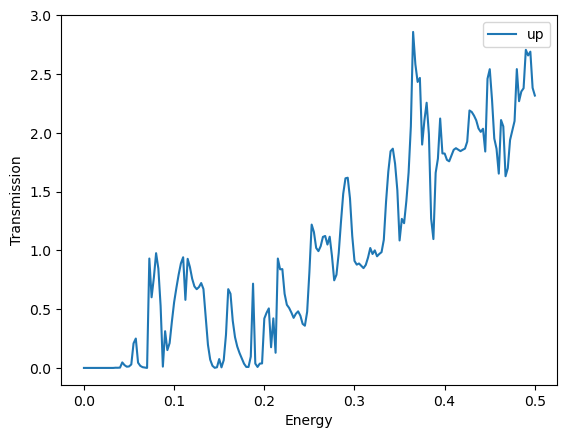

In [488]:
plt.plot(es4, trans_up4, label='up')

plt.xlabel('Energy')
plt.ylabel('Transmission')
plt.legend()
plt.show()

In [590]:
#load folder 1 NM clean 
foldernm = Path("nmsystems/ZGNR_20_L30_p0.05_n20_20260207_221825")  # change for diff folders 

# one configuration file tranport 
filenm = foldernm / "conf_0001_transport_results.npz"
datanm = np.load(filenm)
# one configuration file structure
structurenm = foldernm / "conf_0001_structure_data.npz"
strucdatanm = np.load(structurenm, allow_pickle=True)

print(strucdatanm.files)
print(datanm.files)

['a', 'subs', 'dmat', 'cells', 'h_dev', 'h_lead', 'vlr_lead', 'onsites', 'dev_sites_l', 'dev_sites_r', 'llead_ind', 'rlead_ind', 'vdevl_lead', 'vdevr_lead', 'conf_id', 'edge_prob', 'num_etchs', 'disorder_length', 'padding', 'z_index']
['conf_id', 'energies', 'transmission', 'edge_prob', 'num_etchs', 'disorder_length', 'padding', 'z_index']


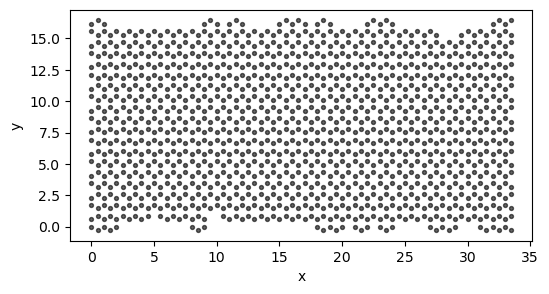

In [592]:
coords = strucdatanm["a"]   # atomic coordinates

fig, ax = plt.subplots(figsize=(10, 3))

ax.scatter(coords[:, 0], coords[:, 1], s=8, c="k", alpha=0.6)
ax.set_aspect("equal")

ax.set_xlabel("x")
ax.set_ylabel("y")
# ax.set_title(f"Atomic structure – conf {conf_id}")
# plt.savefig
plt.show()

In [586]:
# x=strcdata[,,1]
# y= strcdata[,,0]
energiesnm = datanm["energies"]
transmissionnm = datanm["transmission"]

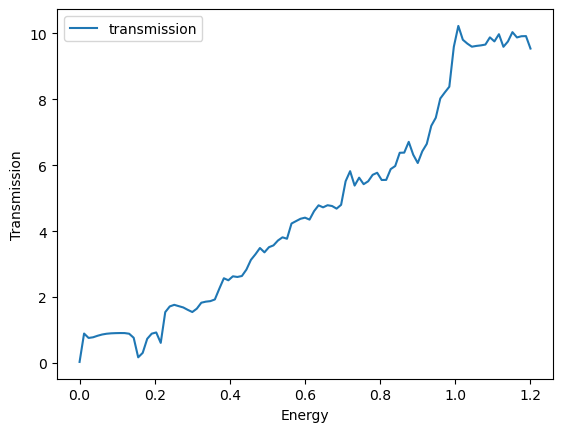

In [588]:
plt.plot(energiesnm, transmissionnm, label='transmission')

plt.xlabel('Energy')
plt.ylabel('Transmission')
plt.legend()
plt.show()

In [562]:
save_path = Path("nmsystems/20-30-cleanplot_data.npz")

np.savez(
    save_path,
    energiesnm=energiesnm,
    transmissionnm=transmissionnm,
)

print(f"Saved plot data to: {save_path}")

Saved plot data to: nmsystems/20-30-cleanplot_data.npz


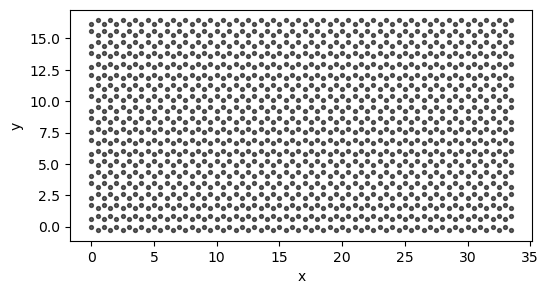

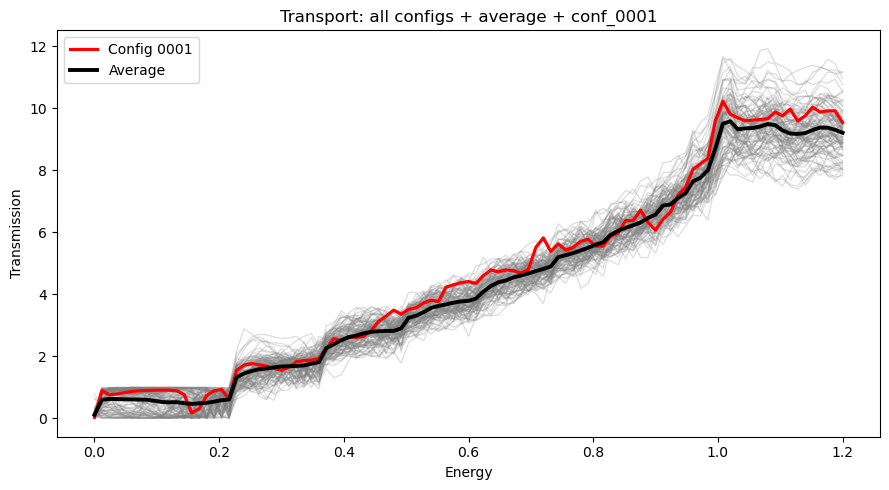

In [572]:

folder = Path("nmsystems/ZGNR_20_L30_p0.05_n20_20260207_221825")

# ---- load all configs ----
all_files4 = sorted(folder.glob("conf_*_transport_results.npz"))

all_transmissions4 = []
energies = None

for f in all_files4:
    data = np.load(f)
    if energies is None:
        energies = data["energies"]        # same for all configs
    all_transmissions4.append(data["transmission"])

Transmissions_combined4 = np.array(all_transmissions4)   # (N_configs, N_energies)

# ---- load config 0001 explicitly ----
file_conf1 = folder / "conf_0001_transport_results.npz"
data1 = np.load(file_conf1)
T_conf1 = data1["transmission"]

# ---- average ----
T_avg = np.nanmean(Transmissions_combined4, axis=0)

# ---- plot ----
plt.figure(figsize=(9,5))

# all configs: grey transparent
for i in range(Transmissions_combined4.shape[0]):
    plt.plot(energies, Transmissions_combined4[i],
             color="grey", alpha=0.25, lw=1)

# config 0001: red
plt.plot(energies, T_conf1,
         color="red", lw=2.3, label="Config 0001")

# average: black
plt.plot(energies, T_avg,
         color="black", lw=2.8, label="Average")

plt.xlabel("Energy")
plt.ylabel("Transmission")
plt.title("Transport: all configs + average + conf_0001")
plt.legend()
plt.tight_layout()
plt.savefig(".05 average plot.png", dpi=300)
plt.show()



In [546]:
save_path = Path("nmsystems/20-30-0.05plot_data.npz")

np.savez(
    save_path,
    energies=energies,
    all_transmissions=Transmissions_combined4,
    avg_transmission=T_avg,
    conf1_transmission=T_conf1
)

print(f"Saved plot data to: {save_path}")

Saved plot data to: nmsystems/20-30-0.05plot_data.npz


In [566]:
data01 = np.load("nmsystems/20-30-0.01plot_data.npz")
data02 = np.load("nmsystems/20-30-0.02plot_data.npz")
data05 = np.load("nmsystems/20-30-0.05plot_data.npz")
dataclean = np.load("nmsystems/20-30-cleanplot_data.npz")

E1 = data01["energies"]
T_all1 = data01["all_transmissions"]
T_avg1 = data01["avg_transmission"]
T_conf1 = data01["conf1_transmission"]

E2 = data02["energies"]
T_all2 = data02["all_transmissions"]
T_avg2 = data02["avg_transmission"]
T_conf2 = data02["conf1_transmission"]

E5 = data05["energies"]
T_all5 = data05["all_transmissions"]
T_avg5 = data05["avg_transmission"]
T_conf5 = data05["conf1_transmission"]

energies = dataclean["energiesnm"]
transmission = dataclean["transmissionnm"]


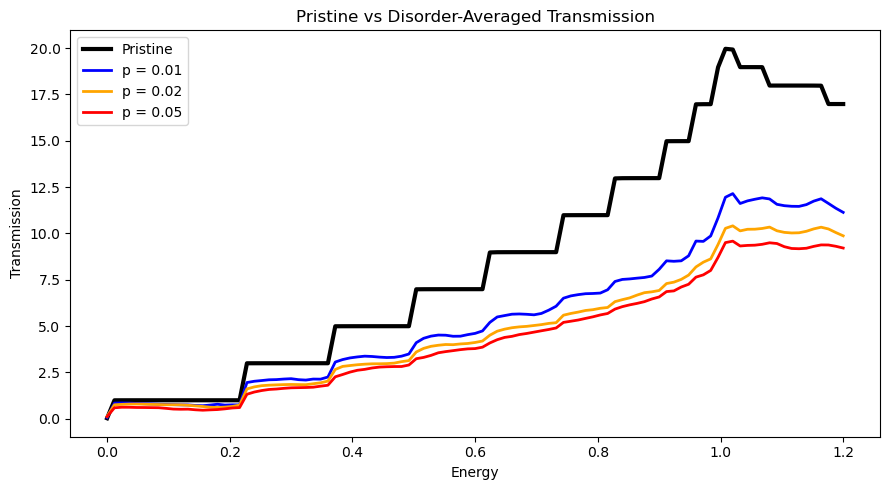

In [570]:
plt.figure(figsize=(9,5))

# ---- clean (reference) ----
plt.plot(energies, transmission,
         color="black", lw=3, label="Pristine")

# ---- disorder averages ----
plt.plot(E1, T_avg1,
         color="blue", lw=2, label="p = 0.01")

plt.plot(E2, T_avg2,
         color="orange", lw=2, label="p = 0.02")

plt.plot(E5, T_avg5,
         color="red", lw=2, label="p = 0.05")

plt.xlabel("Energy")
plt.ylabel("Transmission")
plt.title("Pristine vs Disorder-Averaged Transmission")
plt.legend()
plt.tight_layout()
plt.savefig("pristine and disorder 30.png", dpi=300)
plt.show()